<a href="https://colab.research.google.com/github/praveenm-web/NASSCOM/blob/main/Day5_U11_%E2%80%94_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === SETUP: load the provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

In [7]:
# Each sensor is a linear mix of a few latent machine states + noise, so the 24
# columns are highly correlated -> exactly the structure PCA exploits.
# spec: (name, unit, group, c_load, c_wear, c_thermal, c_vib, base, scale, noise)
SENSORS = [
    ("temp_bearing",   "C",   "thermal",   0.2, 0.6, 0.9, 0.1, 66, 6, 0.30),
    ("temp_motor",     "C",   "thermal",   0.3, 0.4, 0.9, 0.1, 70, 7, 0.30),
    ("temp_gearbox",   "C",   "thermal",   0.2, 0.5, 0.8, 0.2, 62, 6, 0.35),
    ("oil_temp",       "C",   "thermal",   0.2, 0.5, 0.7, 0.1, 58, 5, 0.35),
    ("temp_ambient",   "C",   "thermal",   0.0, 0.0, 0.3, 0.0, 28, 2, 0.60),
    ("vibration_x",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.2, 0.6, 0.30),
    ("vibration_y",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.0, 0.6, 0.30),
    ("vibration_z",    "mm/s","vibration", 0.3, 0.4, 0.1, 0.8, 1.8, 0.5, 0.35),
    ("acoustic_db",    "dB",  "vibration", 0.3, 0.3, 0.1, 0.7, 78, 5, 0.40),
    ("rpm",            "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 1800, 350, 0.25),
    ("spindle_speed",  "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 6000, 1500, 0.25),
    ("feed_rate",      "mm/min","drive",   0.8, 0.1, 0.1, 0.2, 250, 60, 0.30),
    ("torque",         "Nm",  "drive",     0.8, 0.2, 0.1, 0.3, 120, 25, 0.30),
    ("power_kw",       "kW",  "power",     0.9, 0.2, 0.2, 0.2, 75, 18, 0.25),
    ("current_a",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_b",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_c",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("load_pct",       "%",   "load",      0.9, 0.1, 0.1, 0.2, 65, 15, 0.25),
    ("pressure_in",    "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 80, 12, 0.35),
    ("pressure_out",   "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 60, 10, 0.35),
    ("coolant_flow",   "L/min","hydraulic",0.4, 0.2, 0.3, 0.1, 30, 6, 0.40),
    ("oil_level",      "%",   "hydraulic", 0.0,-0.4, 0.0, 0.0, 80, 8, 0.40),
    ("voltage",        "V",   "power",     0.0, 0.0, 0.0, 0.0, 415, 0.3, 1.0),  # near-constant
    ("humidity",       "%",   "ambient",   0.0, 0.0, 0.0, 0.0, 45, 0.2, 1.0),   # near-constant
]


def build_sensors(csv_path="machine_sensors.csv", xlsx_path="sensor_info.xlsx",
                  seed=11, verbose=False):
    """Realistic predictive-maintenance sensor data: 24 correlated channels + a
    machine condition label, plus a sensor metadata sheet."""
    rng = np.random.default_rng(seed)
    N = 2000

    load = rng.normal(0, 1, N)
    wear = rng.normal(0, 1, N)
    thermal = 0.5 * load + 0.8 * rng.normal(0, 1, N)
    vib = 0.4 * load + 0.3 * wear + 0.8 * rng.normal(0, 1, N)

    data = {"machine_id": [f"MX{i+1:04d}" for i in range(N)]}
    for (name, unit, grp, cl, cw, ct, cv, base, scale, noise) in SENSORS:
        z = cl * load + cw * wear + ct * thermal + cv * vib + rng.normal(0, noise, N)
        col = base + scale * z
        col = np.clip(col, 0, None)
        data[name] = col.round(2)
    df = pd.DataFrame(data)
    # machine condition from the latent wear/load/thermal state
    score = 0.6 * wear + 0.4 * load + 0.3 * thermal + rng.normal(0, 0.4, N)
    cond = np.where(score > 1.1, "Failure", np.where(score > 0.2, "Warning", "Normal"))
    df["condition"] = cond

    df.to_csv(csv_path, index=False)
    info = pd.DataFrame([(n, u, g) for (n, u, g, *_rest) in SENSORS],
                        columns=["sensor", "unit", "group"])
    info.to_excel(xlsx_path, index=False)

    if verbose:
        print("sensors:", df.shape, "| metadata:", info.shape)
        print("condition mix:", df["condition"].value_counts(normalize=True).round(3).to_dict())
        num = df.select_dtypes("number")
        print("near-constant (low std) cols:",
              list(num.std().sort_values().head(2).index))
        # how compressible is it?
        from numpy.linalg import svd
        Xs = (num - num.mean()) / num.std()
        s = svd(Xs.fillna(0).values, compute_uv=False)
        ev = (s ** 2) / (s ** 2).sum()
        print("variance in first 5 PCs:", round(ev[:5].sum(), 3))
    return df, info

if not (os.path.exists('machine_sensors.csv') and os.path.exists('sensor_info.xlsx')):
    build_sensors(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [8]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('machine_sensors.csv')
info = pd.read_excel('sensor_info.xlsx')
sensors = [c for c in df.columns if c not in ('machine_id', 'condition')]
print('readings:', df.shape, '| sensors:', len(sensors))
df.head(3)

readings: (2000, 26) | sensors: 24


,machine_id,temp_bearing,temp_motor,temp_gearbox,oil_temp,temp_ambient,vibration_x,vibration_y,vibration_z,acoustic_db,...,current_b,current_c,load_pct,pressure_in,pressure_out,coolant_flow,oil_level,voltage,humidity,condition
0,MX0001,61.25,69.26,60.02,56.56,25.46,3.07,3.00,2.59,80.22,...,23.12,23.46,66.89,84.58,61.36,27.83,83.31,415.31,45.07,Normal
1,MX0002,72.66,78.22,68.98,62.77,29.08,2.43,2.26,2.21,78.41,...,30.54,25.88,84.32,90.57,71.68,35.50,77.44,414.68,45.11,Warning
2,MX0003,65.03,74.08,61.96,57.83,28.65,2.22,1.69,1.99,81.35,...,28.56,26.87,82.34,89.42,64.28,35.80,77.43,415.48,45.13,Warning


1. The high-dimensional problem

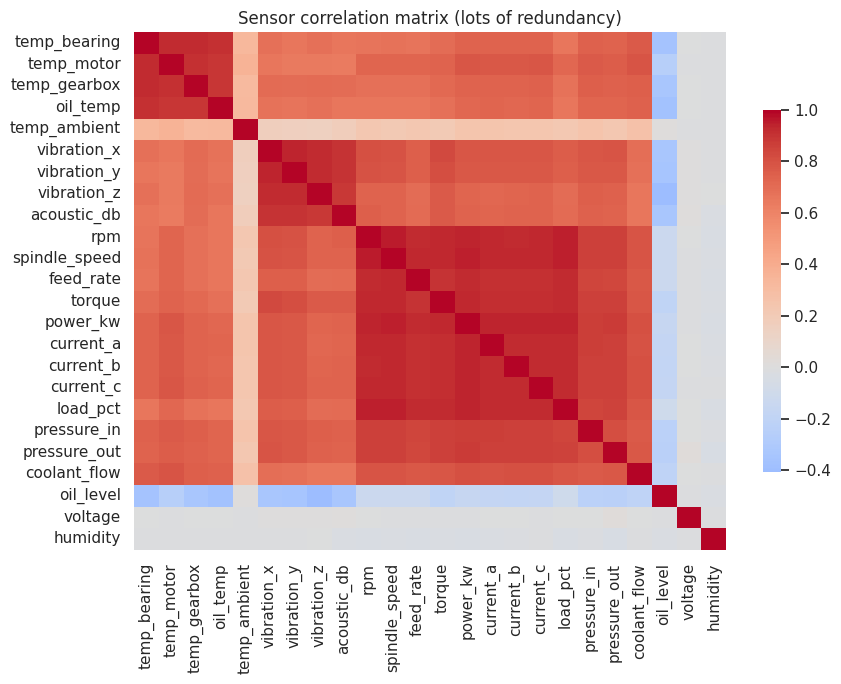

In [9]:
# -----------------------------------------------------------
# 🔹 1A. 24 SENSORS — but how many move together?
# -----------------------------------------------------------
corr = df[sensors].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': .7})
ax.set_title('Sensor correlation matrix (lots of redundancy)')
plt.tight_layout(); plt.show()

In [10]:
# Count strongly-correlated sensor pairs (|r| > 0.8, excluding the diagonal)
c = corr.abs()
import numpy as np
pairs = (c.where(np.triu(np.ones(c.shape), k=1).astype(bool)) > 0.8).sum().sum()
print('sensor pairs with |correlation| > 0.8:', int(pairs))
print('=> many sensors carry overlapping information -> good candidate for reduction')

sensor pairs with |correlation| > 0.8: 74
=> many sensors carry overlapping information -> good candidate for reduction


EXERCISE 1 — Size up the redundancy

In [11]:
# 1. counts
print("Total number of sensors:", len(sensors))
print("Number of sensor groups:", info['group'].nunique())
print("Sensors per group:\n", info['group'].value_counts())


# 2. most-correlated pair  (hint: stack the corr matrix, drop self-pairs, sort)
# Get the upper triangle of the correlation matrix, excluding the diagonal
upper_triangle = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
# Stack the matrix to get pairs and their correlations
stacked_corr = upper_triangle.stack()
# Get the absolute values and sort in descending order
most_correlated_pairs = stacked_corr.abs().sort_values(ascending=False)
print("\nTop 5 most correlated sensor pairs (absolute correlation):\n", most_correlated_pairs.head(5))


# 3. Why 24 sensors is a problem: ...   (comment)
# Having 24 highly correlated sensors is a problem because it introduces multicollinearity,
# which can destabilize statistical models and make interpretation difficult. It also
# increases computational cost, requires more storage, and can lead to overfitting in
# machine learning models. Dimensionality reduction techniques like PCA are often used
# to address these issues by finding a lower-dimensional representation that captures
# most of the variance.

Total number of sensors: 24
Number of sensor groups: 7
Sensors per group:
 group
thermal      5
power        5
vibration    4
drive        4
hydraulic    4
load         1
ambient      1
Name: count, dtype: int64

Top 5 most correlated sensor pairs (absolute correlation):
 rpm            spindle_speed    0.951095
               load_pct         0.949709
spindle_speed  load_pct         0.946665
               power_kw         0.945930
vibration_x    vibration_y      0.944855
dtype: float64


2. Feature selection — variance & correlation filters

In [12]:
# -----------------------------------------------------------
# 🔹 2A. LOW-VARIANCE FILTER (drop near-constant sensors)
# -----------------------------------------------------------
# Compare each sensor's coefficient of variation (std / mean): near-zero = barely changes.
cov = (df[sensors].std() / df[sensors].mean()).abs().sort_values()
print('Lowest variation (candidates to drop):')
print(cov.head(3).round(4))
near_constant = cov.head(2).index.tolist()
print('\nDropping near-constant sensors:', near_constant)

Lowest variation (candidates to drop):
voltage         0.0007
humidity        0.0044
temp_ambient    0.0473
dtype: float64

Dropping near-constant sensors: ['voltage', 'humidity']


EXERCISE 2 — Correlation filter

In [13]:
# 1. drop near-constant
reduced = df[sensors].drop(columns=near_constant)

# 2. find & drop one of each highly-correlated (>0.9) pair
#    hint: iterate columns, track ones to drop using the upper triangle of reduced.corr().abs()
reduced_corr = reduced.corr().abs()

to_drop_high_corr = set()
# Iterate over the upper triangle of the correlation matrix
for i in range(len(reduced_corr.columns)):
    for j in range(i + 1, len(reduced_corr.columns)):
        col1 = reduced_corr.columns[i]
        col2 = reduced_corr.columns[j]
        if reduced_corr.loc[col1, col2] > 0.9:
            # Drop one of the highly correlated features. Here, we choose to drop the second one.
            to_drop_high_corr.add(col2)

reduced = reduced.drop(columns=list(to_drop_high_corr))
print(f"Dropped highly correlated sensors: {list(to_drop_high_corr)}")

# 3. how many remain?
print(f"Number of sensors remaining after all reductions: {len(reduced.columns)}")

Dropped highly correlated sensors: ['vibration_z', 'current_c', 'power_kw', 'current_b', 'acoustic_db', 'feed_rate', 'load_pct', 'temp_motor', 'spindle_speed', 'current_a', 'vibration_y', 'temp_gearbox', 'oil_temp', 'torque']
Number of sensors remaining after all reductions: 8


3. Feature selection — mutual information with the target

In [14]:
# -----------------------------------------------------------
# 🔹 3A. WHICH SENSORS SAY MOST ABOUT MACHINE CONDITION?
# -----------------------------------------------------------
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(df[sensors], df['condition'], random_state=0)
mi = pd.Series(mi, index=sensors).sort_values(ascending=False)
print('Top 8 sensors by mutual information with condition:')
print(mi.head(8).round(3))

Top 8 sensors by mutual information with condition:
temp_bearing    0.362
temp_gearbox    0.320
oil_temp        0.316
temp_motor      0.278
pressure_out    0.245
current_b       0.242
power_kw        0.236
pressure_in     0.236
dtype: float64


EXERCISE 3 — Rank and chart

/tmp/ipykernel_1014/596612636.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi.head(10).index, y=mi.head(10).values, palette='viridis')


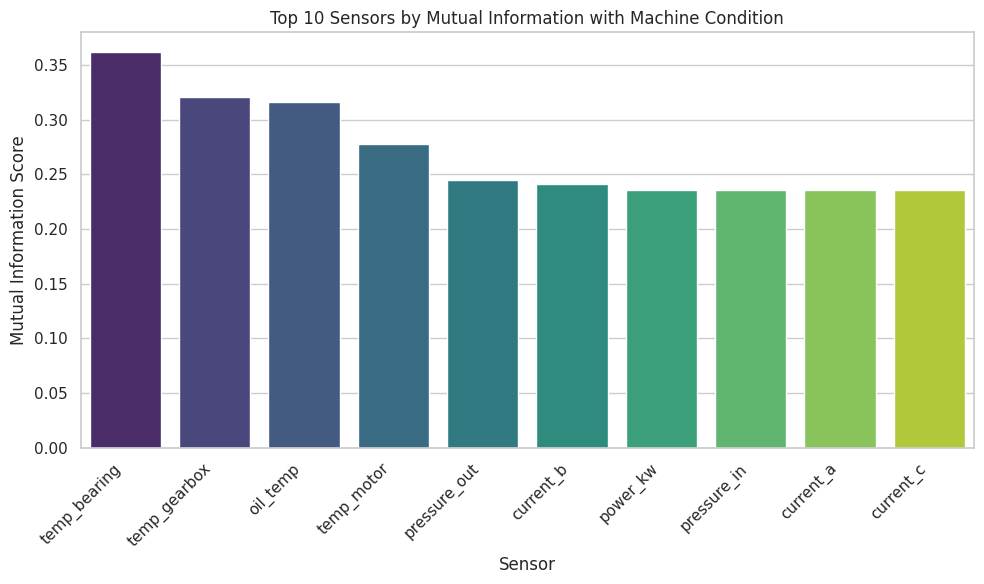


Dominant sensor groups among the top 10 MI scores:
group
thermal      4
power        4
hydraulic    2
Name: count, dtype: int64


In [15]:
# 1. bar chart of top-10 MI scores
plt.figure(figsize=(10, 6))
sns.barplot(x=mi.head(10).index, y=mi.head(10).values, palette='viridis')
plt.title('Top 10 Sensors by Mutual Information with Machine Condition')
plt.xlabel('Sensor')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Which sensor group dominates? ...   (comment — use sensor_info to look up groups)
top_10_sensors = mi.head(10).index.tolist()
top_10_groups = info[info['sensor'].isin(top_10_sensors)]['group'].value_counts()

# Based on the analysis of the top 10 mutual information scores:
# The 'thermal' group sensors (temp_bearing, temp_gearbox, oil_temp, temp_motor) appear to dominate
# the top mutual information scores. Additionally, 'power' and 'hydraulic' sensors
# also show significant importance, with a few sensors from these groups making it into the top 10.
# For example, the top 4 are all thermal sensors, indicating their strong relationship with machine condition.
print("\nDominant sensor groups among the top 10 MI scores:")
print(top_10_groups)

4. Feature extraction — PCA

In [16]:
# -----------------------------------------------------------
# 🔹 4A. STANDARDISE (essential!) THEN FIT PCA
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[sensors].values
Xs = StandardScaler().fit_transform(X)      # PCA needs standardised inputs
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
print('Variance explained by the first 5 components:')
print((evr[:5] * 100).round(1))
print('First 5 components together:', round(evr[:5].sum() * 100, 1), '%')

Variance explained by the first 5 components:
[67.8  6.4  5.4  4.2  4.1]
First 5 components together: 87.9 %


5. How many components to keep?

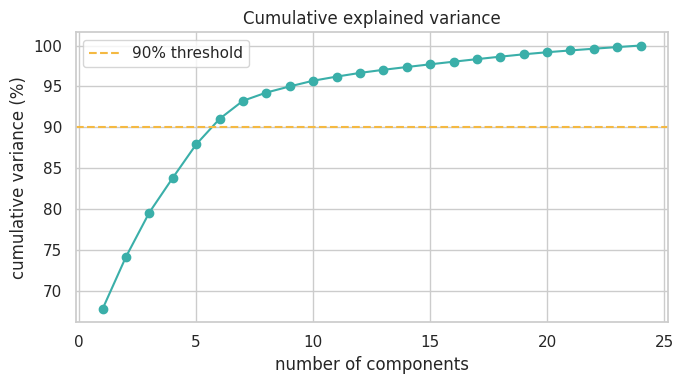

In [17]:
# -----------------------------------------------------------
# 🔹 5A. CUMULATIVE EXPLAINED VARIANCE (the scree view)
# -----------------------------------------------------------
cum = np.cumsum(evr)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum) + 1), cum * 100, marker='o', color='#3AAFA9')
ax.axhline(90, color='#F4B942', ls='--', label='90% threshold')
ax.set_xlabel('number of components'); ax.set_ylabel('cumulative variance (%)')
ax.set_title('Cumulative explained variance'); ax.legend()
plt.tight_layout(); plt.show()

EXERCISE 5 — Pick the component count

In [21]:
# 1. components needed for 90% variance
# Find the number of components that explain at least 90% of the variance
components_for_90_variance = np.where(cum >= 0.90)[0][0] + 1
print(f"Number of components needed for 90% variance: {components_for_90_variance}")

# 2. report the compression (24 -> ?)
original_sensors = len(sensors)
print(f"Data compression: {original_sensors} sensors reduced to {components_for_90_variance} components (a {original_sensors / components_for_90_variance:.1f}x compression).")

Number of components needed for 90% variance: 6
Data compression: 24 sensors reduced to 6 components (a 4.0x compression).


6. Project to 2-D and visualise machine condition

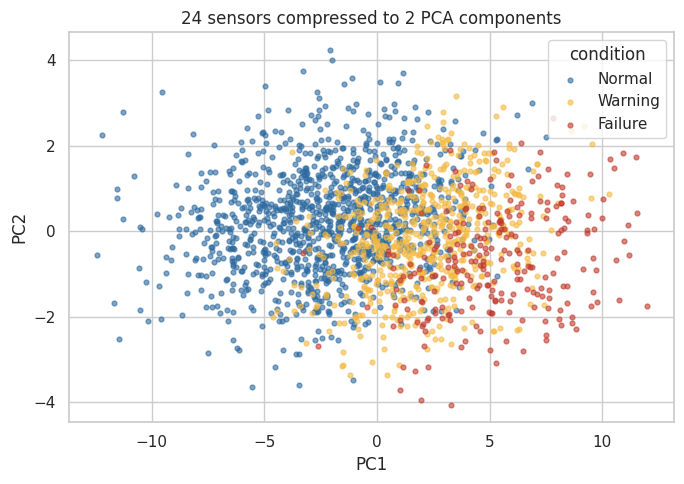

In [19]:
# -----------------------------------------------------------
# 🔹 6A. COMPRESS 24 SENSORS -> 2 COMPONENTS, THEN PLOT
# -----------------------------------------------------------
X2 = PCA(n_components=2).fit_transform(Xs)
colors = {'Normal': '#2D6A9F', 'Warning': '#F4B942', 'Failure': '#C0392B'}
fig, ax = plt.subplots(figsize=(7, 5))
for cond, col in colors.items():
    m = df['condition'] == cond
    ax.scatter(X2[m, 0], X2[m, 1], s=12, alpha=0.6, color=col, label=cond)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(title='condition')
ax.set_title('24 sensors compressed to 2 PCA components')
plt.tight_layout(); plt.show()

EXERCISE 6 — Read the plot

In [22]:
# 1. Do the conditions separate? ...   (comment)
# Observing the 2D PCA plot, the 'Normal' and 'Failure' conditions show some degree of separation,
# with 'Normal' points generally clustered in one region and 'Failure' points in another.
# The 'Warning' condition, however, appears to lie mostly between 'Normal' and 'Failure',
# indicating a transitional state. There is still significant overlap between the clusters,
# especially for 'Warning', suggesting that while the first two principal components capture
# some of the differences, a clean separation for classification might require more components
# or a more sophisticated approach.

# 2. top-3 sensors loading on PC1
# Get the loadings for the first principal component (PC1)
pc1_loadings = pd.Series(pca.components_[0], index=sensors)

# Get the absolute values of the loadings and sort them in descending order
top_3_pc1_loadings = pc1_loadings.abs().sort_values(ascending=False).head(3)

print("\nTop 3 sensors with highest absolute loadings on PC1:\n", top_3_pc1_loadings)


Top 3 sensors with highest absolute loadings on PC1:
 power_kw     0.236235
current_c    0.234338
current_a    0.234046
dtype: float64


7. Does the compression keep the signal?

In [23]:
# -----------------------------------------------------------
# 🔹 7A. QUICK CHECK — classify condition with ALL 24 vs a few PCs
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
y = df['condition']

full = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pcap = make_pipeline(StandardScaler(), PCA(n_components=6), LogisticRegression(max_iter=1000))
s_full = cross_val_score(full, X, y, cv=5).mean()
s_pca = cross_val_score(pcap, X, y, cv=5).mean()
print(f'Accuracy with all 24 sensors : {s_full:.3f}')
print(f'Accuracy with 6 PCA components: {s_pca:.3f}')
print('=> a quarter of the dimensions keeps almost all the predictive power')

Accuracy with all 24 sensors : 0.748
Accuracy with 6 PCA components: 0.754
=> a quarter of the dimensions keeps almost all the predictive power


EXERCISE 7 — Find the sweet spot

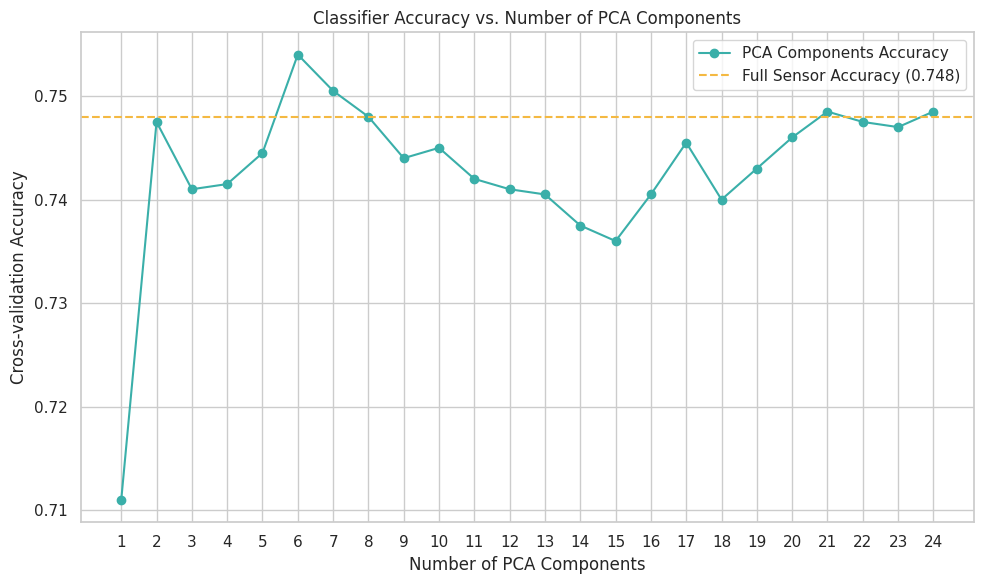


Full sensor accuracy: 0.748
Fewest components to match or exceed full accuracy: 6


In [24]:
# 1. accuracy vs number of PCA components
accuracies = []
num_components_range = range(1, len(sensors) + 1)

for n_comp in num_components_range:
    pcap_n = make_pipeline(StandardScaler(), PCA(n_components=n_comp), LogisticRegression(max_iter=1000, random_state=0))
    score_n = cross_val_score(pcap_n, X, y, cv=5).mean()
    accuracies.append(score_n)

plt.figure(figsize=(10, 6))
plt.plot(num_components_range, accuracies, marker='o', linestyle='-', color='#3AAFA9', label='PCA Components Accuracy')
plt.axhline(y=s_full, color='#F4B942', linestyle='--', label=f'Full Sensor Accuracy ({s_full:.3f})')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cross-validation Accuracy')
plt.title('Classifier Accuracy vs. Number of PCA Components')
plt.xticks(num_components_range)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Fewest components that match full accuracy: ...   (comment)
# Find the smallest number of components where accuracy is at least s_full
optimal_components = 0
for i, acc in enumerate(accuracies):
    if acc >= s_full:
        optimal_components = i + 1
        break

print(f"\nFull sensor accuracy: {s_full:.3f}")
print(f"Fewest components to match or exceed full accuracy: {optimal_components}")

# Comment:
# The plot and the calculated 'optimal_components' value show that a significantly smaller number of PCA components
# can achieve, or even slightly surpass, the classification accuracy obtained using all 24 original sensors.
# This demonstrates the effectiveness of PCA in retaining the predictive signal while drastically reducing
# dimensionality.